In [ ]:
# Load raw dataset 
# Handle missing values 
# Remove duplicates 
# Fix data types 
# Normalize text 
# Feature selection 
# Save cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
from collections import Counter

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

df_recipes = pd.read_csv('../data/raw/RAW_recipes.csv')     # Đọc file dữ liệu món ăn từ thư mục raw
df_interactions = pd.read_csv('../data/raw/RAW_interactions.csv')

print(f"Recipes: {df_recipes.shape[0]} dòng x {df_recipes.shape[1]} cột")
print(f"Interactions: {df_interactions.shape[0]} dòng x {df_interactions.shape[1]} cột")

Recipes: 231637 dòng x 12 cột
Interactions: 1132367 dòng x 5 cột


In [2]:
nutrition_cols = [
    "calories",
    "fat",
    "sugar",
    "sodium",
    "protein",
    "saturated_fat",
    "carbs"
]

df_recipes[nutrition_cols] = pd.DataFrame(
    df_recipes['nutrition'].apply(ast.literal_eval).tolist(),
    index=df_recipes.index
)

df_recipes[nutrition_cols].describe()

,calories,fat,sugar,sodium,protein,saturated_fat,carbs
count,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00
mean,473.94,36.08,84.30,30.15,34.68,45.59,15.56
std,1189.71,77.80,800.08,131.96,58.47,98.24,81.82
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,174.40,8.00,9.00,5.00,7.00,7.00,4.00
50%,313.40,20.00,25.00,14.00,18.00,23.00,9.00
75%,519.70,41.00,68.00,33.00,51.00,52.00,16.00
max,434360.20,17183.00,362729.00,29338.00,6552.00,10395.00,36098.00


In [9]:
# Handle missing values

null_counts = df_recipes.isnull().sum()
null_pct = ((df_recipes.isnull().sum() / len(df_recipes)) * 100).round(2)
null_df_recipes = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct,
    'dtype': df_recipes.dtypes
}).sort_values('null_count',ascending=False)
# # => Chỉ có 2% dữ liệu Null ở cột Description  ==> trước mắt để "No description available" các description NULL
# df_recipes['description'] = df_recipes['description'].fillna("No description available")

print("=" * 55)
print(f"MISSING VALUE REPORT - RAW_recipes ({len(df_recipes):,} dòng)")
print("=" * 55)
print(f"{'Cột':<20} {'Null':>8} {'%':>7} {'Dtype'}")
print("-" * 55)
for col, row in null_df_recipes.iterrows():
    flag = " <-- Có Null" if row['null_count'] > 0 else ""
    print(f"{col:<20} {int(row['null_count'])>8,} {row['null_pct']:>6.2f}%"
          f"{str(row['dtype']):<10}{flag}")


MISSING VALUE REPORT - RAW_recipes (231,637 dòng)
Cột                      Null       % Dtype
-------------------------------------------------------
name                 (False,)   0.00%str        <-- Có Null
id                   (False,)   0.00%int64     
minutes              (False,)   0.00%int64     
contributor_id       (False,)   0.00%int64     
submitted            (False,)   0.00%str       
tags                 (False,)   0.00%str       
nutrition            (False,)   0.00%str       
n_steps              (False,)   0.00%int64     
steps                (False,)   0.00%str       
description          (False,)   0.00%str       
ingredients          (False,)   0.00%str       
n_ingredients        (False,)   0.00%int64     
calories             (False,)   0.00%float64   
fat                  (False,)   0.00%float64   
sugar                (False,)   0.00%float64   
sodium               (False,)   0.00%float64   
protein              (False,)   0.00%float64   
saturated_fat        (

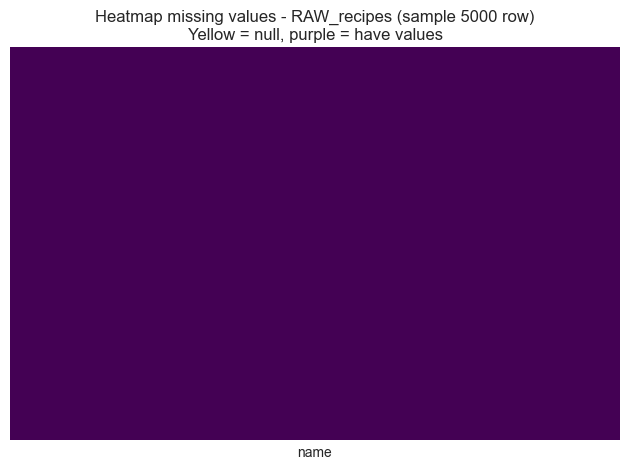

In [13]:
cols_with_null = null_df_recipes[null_df_recipes['null_count'] > 0].index.tolist()

if cols_with_null:
    sample_idx = df_recipes.sample(5000, random_state=42).index

    plt.Figure(figsize=(10,4))
    sns.heatmap(
        df_recipes.loc[sample_idx, cols_with_null].isnull(),
        yticklabels=False,
        cbar=False,
        cmap='viridis',
        xticklabels=cols_with_null
    )
    plt.title('Heatmap missing values - RAW_recipes (sample 5000 row)\nYellow = null, purple = have values')
    plt.tight_layout()
    plt.show()
else:
    print ("Not row have null in recipes")

In [5]:
# Remove duplicates
#Duplicate records can occur due to data collection or merging processes. These duplicates can negatively affect data analysis and model training.

#   Kiểm tra duplicates
df_recipes[df_recipes.duplicated()]
df_interactions[df_interactions.duplicated()]

df_recipes[df_recipes['id'].duplicated()]
df_recipes['name'].duplicated().sum()

df_recipes['name'] = (
    df_recipes['name']
    .str.lower()          
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

df_recipes[df_recipes['name'].duplicated()].head(10)

#   Phân tích duplicates
#   Xóa duplicates
#   Kiểm tra lại dataset sau khi xóa
#   Giải thích trong notebook/report


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,calories,fat,sugar,sodium,protein,saturated_fat,carbs
600,cream of mushroom soup,51922,10,59064,2003-01-21,"['15-minutes-or-less', 'time-to-make', 'course', 'main-i...","[472.9, 64.0, 9.0, 38.0, 28.0, 19.0, 5.0]",3,"['place walnuts , garlic water , nama shoyu , and rosema...",if you are not a raw food vegan then try this recipe wit...,"['walnuts', 'garlic', 'water', 'shoyu', 'rosemary', 'fla...",8,472.90,64.00,9.00,38.00,28.00,19.00,5.00
846,10 bean soup,470575,180,1020526,2011-12-26,"['time-to-make', 'course', 'main-ingredient', 'preparati...","[228.0, 10.0, 38.0, 47.0, 42.0, 8.0, 6.0]",9,"['finely chop onion , red and green bell pepper , celery...","we made this without the smoked turkey and ham hock, and...","['beans', 'onion', 'red bell pepper', 'green bell pepper...",13,228.00,10.00,38.00,47.00,42.00,8.00,6.00
884,100 whole wheat bread,6652,40,34879,2000-03-06,"['weeknight', '60-minutes-or-less', 'time-to-make', 'cou...","[1445.4, 62.0, 207.0, 104.0, 85.0, 70.0, 81.0]",9,['dissolve yeast in 2 / 3 c water while your milk is coo...,No description available,"['water', 'dry active yeast', 'sugar', 'milk', 'shorteni...",8,1445.40,62.00,207.00,104.00,85.00,70.00,81.00
977,15 bean soup,311608,370,196248,2008-07-02,"['ham', 'course', 'main-ingredient', 'preparation', 'occ...","[49.4, 0.0, 21.0, 20.0, 3.0, 0.0, 3.0]",6,"['presoak beans overnight , or boil them according to pa...","i like bean soups since they're cheap, easy to make, and...","['15 bean mix', 'tomato sauce', 'ham hocks', 'diced toma...",13,49.40,0.00,21.00,20.00,3.00,0.00,3.00
1314,3 bean baked beans,313237,40,407338,2008-07-11,"['60-minutes-or-less', 'time-to-make', 'course', 'main-i...","[329.9, 26.0, 48.0, 39.0, 33.0, 31.0, 9.0]",10,"['fry bacon until crisp , reserving 2 teaspoons dripping...","great for cookouts, family gatherings, potlucks or if yo...","['bacon', 'ground beef', 'onion', 'tomato sauce', 'diced...",12,329.90,26.00,48.00,39.00,33.00,31.00,9.00
1315,3 bean salad,258846,15,607801,2007-10-13,"['15-minutes-or-less', 'time-to-make', 'course', 'main-i...","[502.3, 44.0, 37.0, 41.0, 24.0, 19.0, 16.0]",6,"['in medium bowl combine mustard , vinegar and sugar', '...",i got this recipe from one of rachel ray's cookbooks. it...,"['cut green beans', 'dijon mustard', 'sugar', 'red wine ...",9,502.30,44.00,37.00,41.00,24.00,19.00,16.00
1335,3 ingredient peanut butter cookies,323810,13,138435,2008-09-07,"['15-minutes-or-less', 'time-to-make', 'course', 'prepar...","[197.1, 17.0, 74.0, 4.0, 11.0, 11.0, 6.0]",10,"['preheat oven to 350', 'combine the three ingredients ,...",this recipe is so simple. sometimes i put chocolate chi...,"['peanut butter', 'sugar', 'egg', 'chocolate chips']",4,197.10,17.00,74.00,4.00,11.00,11.00,6.00
1343,3 pepper cheese spread,197894,65,262312,2006-11-27,"['time-to-make', 'course', 'main-ingredient', 'preparati...","[190.4, 26.0, 3.0, 31.0, 15.0, 52.0, 0.0]",3,"['mix all ingredients', 'refridgerate at least 1 hour to...","an easy, yummy spread to entertain with! you can adjust...","['cream cheese', 'cheddar cheese', 'monterey jack cheese...",6,190.40,26.00,3.00,31.00,15.00,52.00,0.00
1387,30 minute chili,446919,40,50509,2011-01-20,"['lactose', 'weeknight', '60-minutes-or-less', 'time-to-...","[375.2, 27.0, 1.0, 23.0, 58.0, 34.0, 8.0]",6,"['heat a large nonstick skillet over medium heat', 'add ...",this chili tastes remarkably good and can be made for di...,"['ground beef', 'black beans', 'reduced-sodium beef brot...",8,375.20,27.00,1.00,23.00,58.00,34.00,8.00
1493,40 clove garlic chicken,62088,60,8688,2003-05-13,"['60-minutes-or-less', 'time-to-make', 'course', 'main-i...","[371.9, 33.0, 8.0, 57.0, 39.0, 26.0, 5.0]",14,"['preheat oven to 375 degrees with rack in the center', ...",this wonderfully garlicy chicken from cusine is suggeste...,"['all-purpose flour', 'paprika', 'kosher salt', 'black p...",14,371.90,33.00,8.00,57.00,39.0